In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

points = pd.read_parquet(PROCESSED / "points_context.parquet")
shots = pd.read_parquet(PROCESSED / "shots_context.parquet")

print("Points:", points.shape)
print("Shots: ", shots.shape)

Points: (1353711, 21)
Shots:  (5308401, 14)


In [2]:
# The parser stored how each point ended, but not which shot ended it.
# The final shot of a rally carries the point outcome; every earlier shot
# simply kept the rally alive. This creates the 4-class target for SQ2.
shots = shots.merge(points[["match_id", "Pt", "point_outcome", "rally_length"]],
                    on=["match_id", "Pt"], how="left")

shots["shot_outcome"] = np.where(shots["shot_number"] == shots["rally_length"],
                                 shots["point_outcome"],
                                 "in_play")

# The majority class sets the accuracy floor any model must beat.
distribution = shots["shot_outcome"].value_counts(normalize=True)
print(distribution.round(3))
print(f"\nMajority-class baseline: {distribution.max():.1%}")

shot_outcome
in_play           0.769
unforced_error    0.087
forced_error      0.081
winner            0.063
Name: proportion, dtype: float64

Majority-class baseline: 76.9%


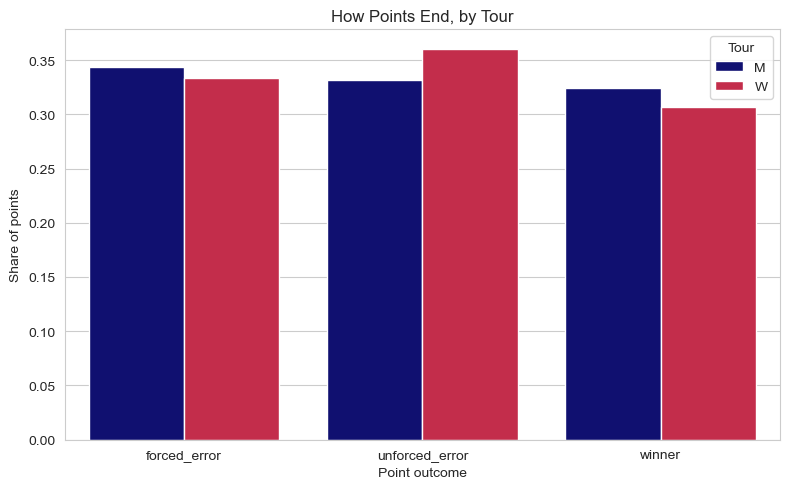

In [3]:
# How points end overall, split by tour. This is the base rate every later
# comparison is measured against.
outcome_by_gender = (points.groupby("gender")["point_outcome"]
                     .value_counts(normalize=True)
                     .rename("share").reset_index())

plt.figure(figsize=(8, 5))
sns.barplot(data=outcome_by_gender, x="point_outcome", y="share", hue="gender",
            palette=["navy", "crimson"])
plt.title("How Points End, by Tour")
plt.xlabel("Point outcome")
plt.ylabel("Share of points")
plt.legend(title="Tour")
plt.tight_layout()
plt.savefig(FIGURES / "outcome_by_gender.png", dpi=150)
plt.show()

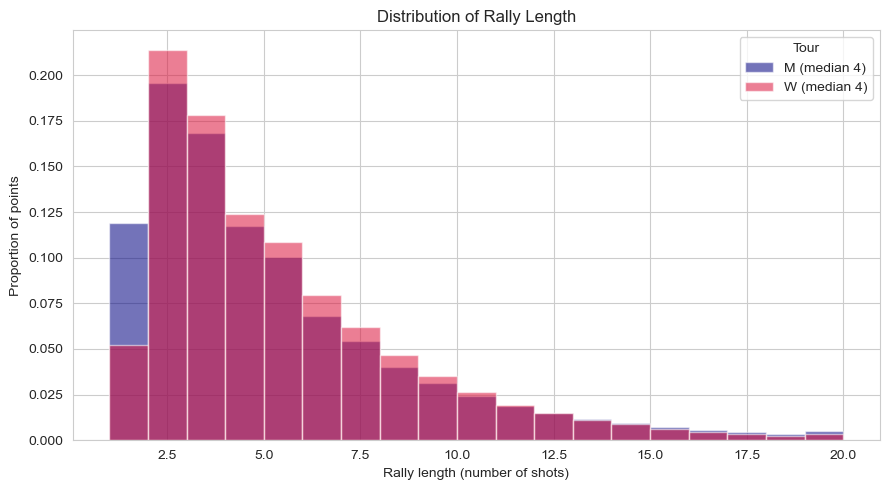

In [4]:
# Rally length is heavily right-skewed: most points are decided early.
# We cap the axis at 20 shots because the long tail is visually useless.
plt.figure(figsize=(9, 5))
for tour, colour in [("M", "navy"), ("W", "crimson")]:
    subset = points.loc[points["gender"] == tour, "rally_length"]
    plt.hist(subset, bins=range(1, 21), density=True, alpha=0.55,
             color=colour, label=f"{tour} (median {subset.median():.0f})")

plt.title("Distribution of Rally Length")
plt.xlabel("Rally length (number of shots)")
plt.ylabel("Proportion of points")
plt.legend(title="Tour")
plt.tight_layout()
plt.savefig(FIGURES / "rally_length_distribution.png", dpi=150)
plt.show()

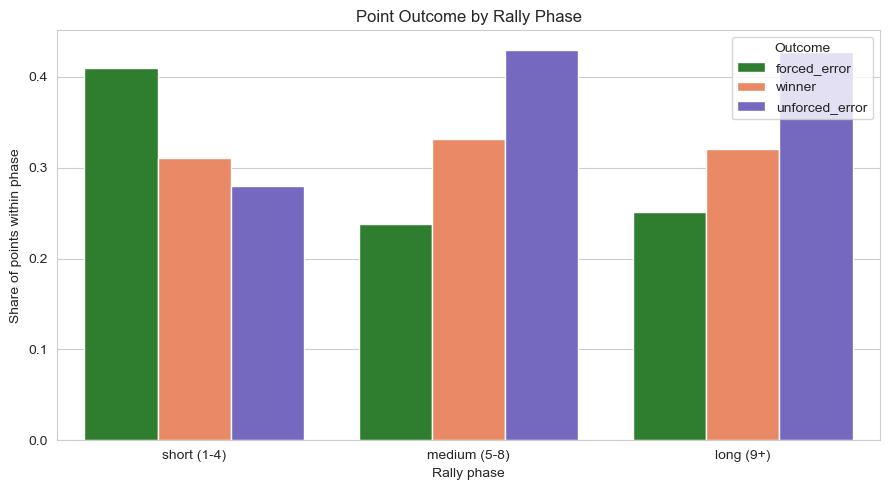

In [5]:
# Rally phase buckets follow the project brief: short, medium, long.
points["rally_phase"] = pd.cut(points["rally_length"],
                               bins=[0, 4, 8, np.inf],
                               labels=["short (1-4)", "medium (5-8)", "long (9+)"])

phase_outcome = (points.groupby("rally_phase", observed=True)["point_outcome"]
                 .value_counts(normalize=True)
                 .rename("share").reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=phase_outcome, x="rally_phase", y="share", hue="point_outcome",
            palette=["forestgreen", "coral", "slateblue"])
plt.title("Point Outcome by Rally Phase")
plt.xlabel("Rally phase")
plt.ylabel("Share of points within phase")
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig(FIGURES / "outcome_by_rally_phase.png", dpi=150)
plt.show()

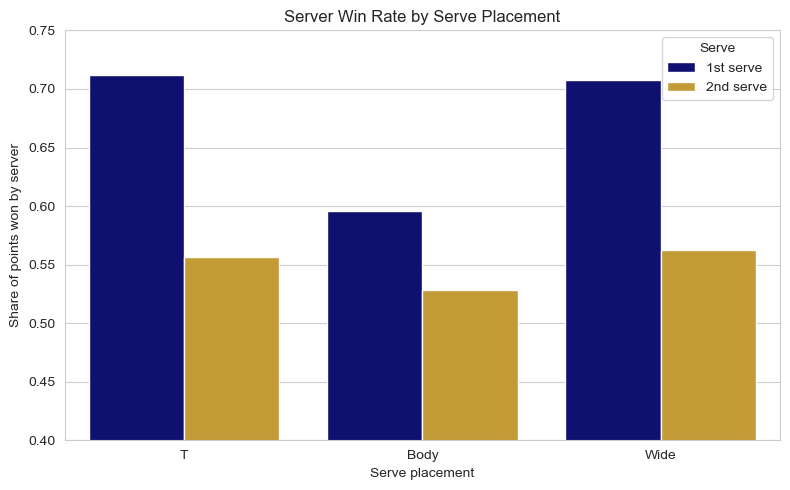

In [6]:
# Server win rate by placement, separated by serve number. First and second
# serves must not be pooled: they are played with different risk appetite.
points["server_won"] = (points["point_winner"] == points["server"])
points["serve_number"] = np.where(points["is_second_serve"], "2nd serve", "1st serve")

serve_effect = (points.dropna(subset=["serve_direction"])
                .groupby(["serve_number", "serve_direction"], observed=True)["server_won"]
                .mean().rename("win_rate").reset_index())

plt.figure(figsize=(8, 5))
sns.barplot(data=serve_effect, x="serve_direction", y="win_rate", hue="serve_number",
            palette=["navy", "goldenrod"], order=["T", "Body", "Wide"])
plt.title("Server Win Rate by Serve Placement")
plt.xlabel("Serve placement")
plt.ylabel("Share of points won by server")
plt.ylim(0.4, 0.75)
plt.legend(title="Serve")
plt.tight_layout()
plt.savefig(FIGURES / "serve_placement_win_rate.png", dpi=150)
plt.show()

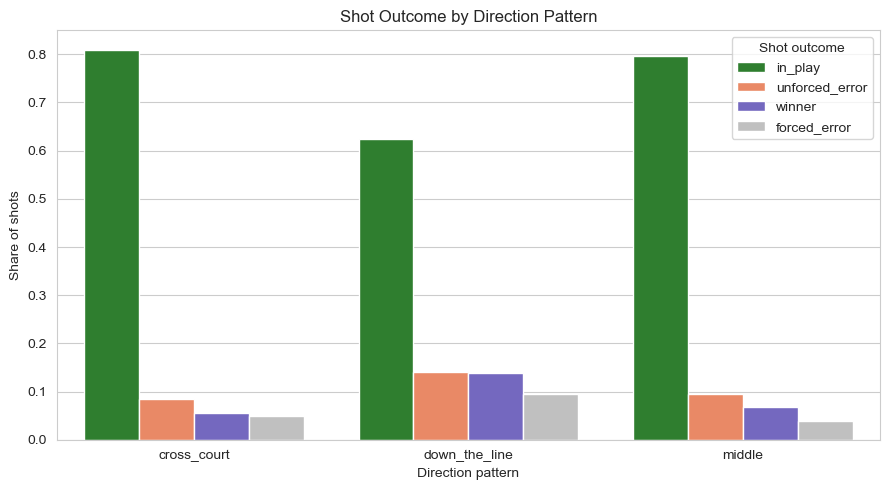

In [7]:
# Cross-court vs down-the-line. This is the core risk-reward comparison
# behind the main research question.
pattern_outcome = (shots.dropna(subset=["direction_pattern"])
                   .groupby("direction_pattern", observed=True)["shot_outcome"]
                   .value_counts(normalize=True)
                   .rename("share").reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=pattern_outcome, x="direction_pattern", y="share", hue="shot_outcome",
            palette=["forestgreen", "coral", "slateblue", "silver"],
            order=["cross_court", "down_the_line", "middle"])
plt.title("Shot Outcome by Direction Pattern")
plt.xlabel("Direction pattern")
plt.ylabel("Share of shots")
plt.legend(title="Shot outcome")
plt.tight_layout()
plt.savefig(FIGURES / "outcome_by_direction_pattern.png", dpi=150)
plt.show()

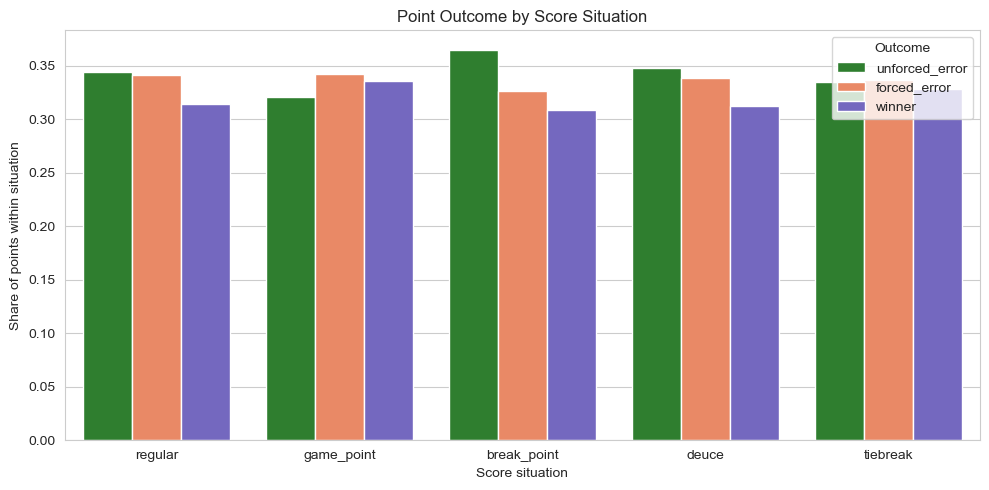

In [8]:
# Point outcome under different score situations.
pressure_outcome = (points.groupby("pressure_context", observed=True)["point_outcome"]
                    .value_counts(normalize=True)
                    .rename("share").reset_index())

order = ["regular", "game_point", "break_point", "deuce", "tiebreak"]

plt.figure(figsize=(10, 5))
sns.barplot(data=pressure_outcome, x="pressure_context", y="share",
            hue="point_outcome", order=order,
            palette=["forestgreen", "coral", "slateblue"])
plt.title("Point Outcome by Score Situation")
plt.xlabel("Score situation")
plt.ylabel("Share of points within situation")
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig(FIGURES / "outcome_by_pressure.png", dpi=150)
plt.show()

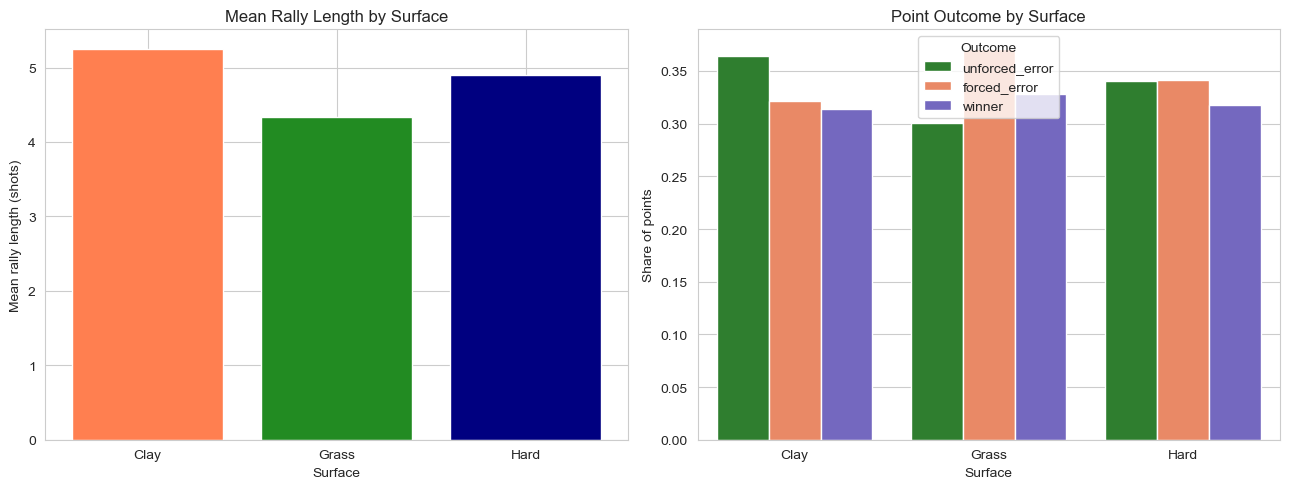

In [9]:
# Surface affects how long rallies last and how points are won.
surface_data = points.dropna(subset=["Surface"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mean_rally = surface_data.groupby("Surface", observed=True)["rally_length"].mean()
axes[0].bar(mean_rally.index, mean_rally.values,
            color=["coral", "forestgreen", "navy"])
axes[0].set_title("Mean Rally Length by Surface")
axes[0].set_xlabel("Surface")
axes[0].set_ylabel("Mean rally length (shots)")

surface_outcome = (surface_data.groupby("Surface", observed=True)["point_outcome"]
                   .value_counts(normalize=True)
                   .rename("share").reset_index())
sns.barplot(data=surface_outcome, x="Surface", y="share", hue="point_outcome",
            palette=["forestgreen", "coral", "slateblue"], ax=axes[1])
axes[1].set_title("Point Outcome by Surface")
axes[1].set_xlabel("Surface")
axes[1].set_ylabel("Share of points")
axes[1].legend(title="Outcome")

plt.tight_layout()
plt.savefig(FIGURES / "surface_effects.png", dpi=150)
plt.show()

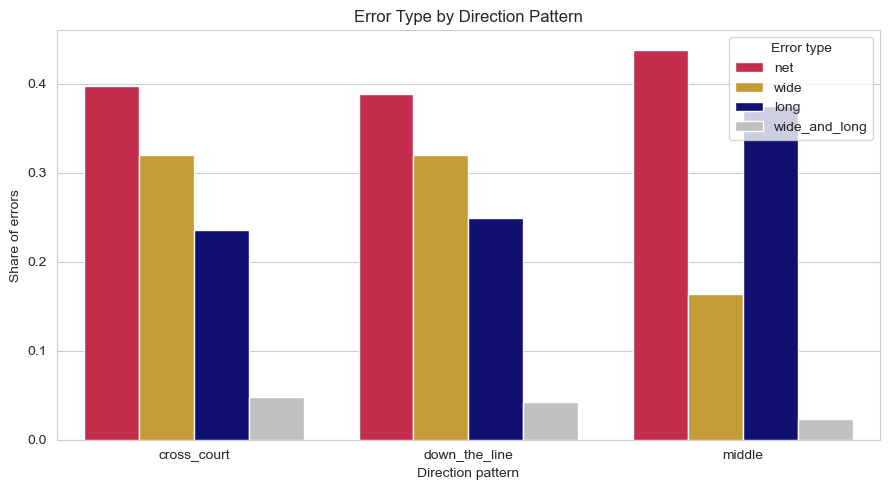

Error coverage: 93.2% of all errors have a recorded type


In [10]:
# How errors are missed: into the net, wide, or long. This tells us whether
# a tactical choice fails through caution (net) or over-hitting (long).
errors = shots.dropna(subset=["error_type", "direction_pattern"])

error_mix = (errors.groupby("direction_pattern", observed=True)["error_type"]
             .value_counts(normalize=True)
             .rename("share").reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=error_mix, x="direction_pattern", y="share", hue="error_type",
            order=["cross_court", "down_the_line", "middle"],
            palette=["crimson", "goldenrod", "navy", "silver"])
plt.title("Error Type by Direction Pattern")
plt.xlabel("Direction pattern")
plt.ylabel("Share of errors")
plt.legend(title="Error type")
plt.tight_layout()
plt.savefig(FIGURES / "error_type_by_direction.png", dpi=150)
plt.show()

print("Error coverage: %.1f%% of all errors have a recorded type"
      % (100 * shots.loc[shots["shot_outcome"].isin(["forced_error", "unforced_error"]),
                         "error_type"].notna().mean()))

In [11]:
from scipy.stats import chi2_contingency

def association_test(data, row_var, col_var):
    """
    Chi-square test of independence plus Cramer's V effect size.

    With samples this large the p-value is almost always near zero, so the
    effect size is what actually tells us whether a relationship matters.
    Cramer's V rule of thumb: 0.1 weak, 0.3 moderate, 0.5 strong.
    """
    table = pd.crosstab(data[row_var], data[col_var])
    chi2, p_value, dof, _ = chi2_contingency(table)

    n = table.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

    return {"comparison": f"{row_var} vs {col_var}", "n": n,
            "chi2": chi2, "p_value": p_value, "cramers_v": cramers_v}

In [12]:
from statsmodels.stats.multitest import multipletests

# Every tactical relationship we claim in the report is tested here.
results = [
    association_test(shots.dropna(subset=["direction_pattern"]),
                     "direction_pattern", "shot_outcome"),
    association_test(shots.dropna(subset=["to_opponent_wing"]),
                     "to_opponent_wing", "shot_outcome"),
    association_test(points.dropna(subset=["serve_direction"]),
                     "serve_direction", "point_outcome"),
    association_test(points, "rally_phase", "point_outcome"),
    association_test(points, "pressure_context", "point_outcome"),
    association_test(points.dropna(subset=["Surface"]),
                     "Surface", "point_outcome"),
    association_test(points, "gender", "point_outcome"),
]

results_df = pd.DataFrame(results)

# Testing seven hypotheses on one dataset inflates the chance of a false
# positive, so p-values are corrected with Benjamini-Hochberg.
_, p_corrected, _, _ = multipletests(results_df["p_value"], method="fdr_bh")
results_df["p_corrected"] = p_corrected

results_df = results_df.sort_values("cramers_v", ascending=False)
print(results_df[["comparison", "n", "cramers_v", "p_corrected"]].to_string(index=False))

                       comparison       n  cramers_v   p_corrected
 to_opponent_wing vs shot_outcome 5193622   0.146835  0.000000e+00
     rally_phase vs point_outcome 1353711   0.133881  0.000000e+00
direction_pattern vs shot_outcome 4004390   0.113958  0.000000e+00
 serve_direction vs point_outcome 1352993   0.091572  0.000000e+00
          gender vs point_outcome 1353711   0.029146 2.290422e-250
         Surface vs point_outcome 1352280   0.027294  0.000000e+00
pressure_context vs point_outcome 1353711   0.019010 6.818235e-206


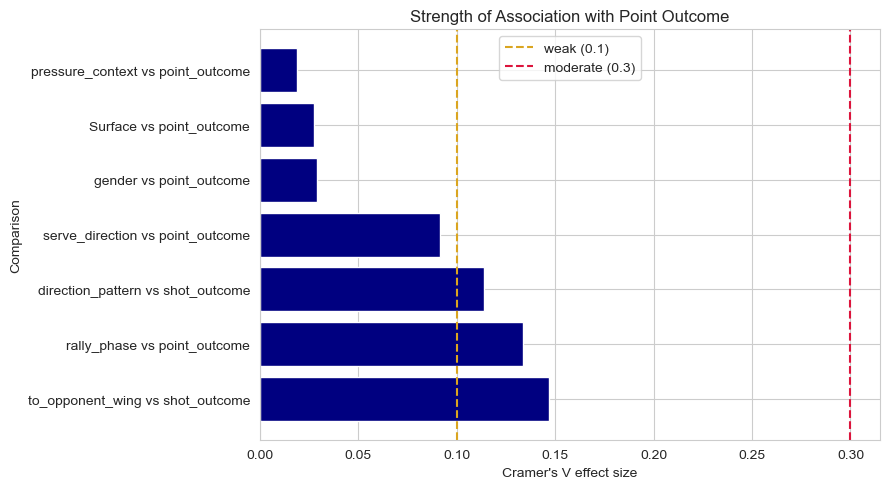

In [13]:
# Rank relationships by strength, not by significance. This chart is the
# honest summary of SQ1: which tactical factors actually matter, and how much.
plt.figure(figsize=(9, 5))
plt.barh(results_df["comparison"], results_df["cramers_v"], color="navy")
plt.axvline(0.1, color="goldenrod", linestyle="--", label="weak (0.1)")
plt.axvline(0.3, color="crimson", linestyle="--", label="moderate (0.3)")
plt.title("Strength of Association with Point Outcome")
plt.xlabel("Cramer's V effect size")
plt.ylabel("Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "effect_sizes.png", dpi=150)
plt.show()

In [14]:
# Save the enriched tables and the test results for the report.
points.to_parquet(PROCESSED / "points_eda.parquet", index=False)
shots.to_parquet(PROCESSED / "shots_eda.parquet", index=False)
results_df.to_csv(PROJECT_ROOT / "figures" / "association_tests.csv", index=False)
print("Saved.")

Saved.
